In [15]:
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

urls = {
    "image1.png":  "https://drive.google.com/uc?export=download&id=1vXrKhy8ugUjgBzAz4cJqhH9emuiItEx8",
    "image2.jpeg": "https://drive.google.com/uc?export=download&id=18ZDun6fXkBkhPzdyrjIt3tyIlWkpVyIy",
    "image3.jpeg": "https://drive.google.com/uc?export=download&id=1NlMpUcwAWYl8f1qAyNtIi_eDV0rX0Vex",
}
for fname, url in urls.items():
    urllib.request.urlretrieve(url, fname)
    print(f"Downloaded {fname}")

Downloaded image1.png
Downloaded image2.jpeg
Downloaded image3.jpeg


image1 (269, 520)
image2 (464, 413)
image3 (850, 850)


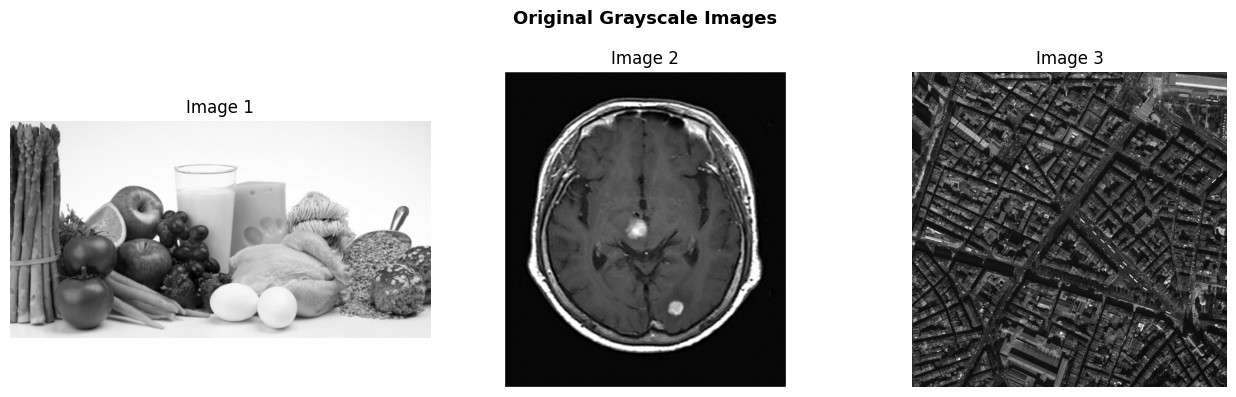

In [16]:
img1 = cv2.imread("image1.png",  cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("image2.jpeg", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("image3.jpeg", cv2.IMREAD_GRAYSCALE)

for name, img in [("image1", img1), ("image2", img2), ("image3", img3)]:
    print(name, img.shape)

plt.figure(figsize=(13, 4))
for i, (name, img) in enumerate([("Image 1", img1), ("Image 2", img2), ("Image 3", img3)]):
    plt.subplot(1, 3, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(name); plt.axis("off")
plt.suptitle("Original Grayscale Images", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

In [17]:
def otsu_fitness(thresholds, image):
    thresholds = np.sort(np.clip(np.array(thresholds, dtype=np.int32), 1, 254))
    hist = np.histogram(image, bins=256, range=(0, 256))[0]
    total_pixels = image.size
    total_mean   = np.mean(image)
    edges = np.concatenate([[0], thresholds, [256]])

    variance = 0.0
    for i in range(len(edges) - 1):
        s, e = edges[i], edges[i+1]
        n_k = np.sum(hist[s:e])
        if n_k == 0:
            continue
        prob   = n_k / total_pixels
        mean_k = np.sum(np.arange(s, e) * hist[s:e]) / n_k
        variance += prob * (mean_k - total_mean) ** 2
    return variance

print("otsu_fitness defined OK")

otsu_fitness defined OK


In [18]:
def gwo(fitness_func, dim, bounds, n_agents=25, max_iter=60, image=None):
    lo, hi = bounds
    alpha = np.zeros(dim); beta = np.zeros(dim); delta = np.zeros(dim)
    alpha_s = beta_s = delta_s = -np.inf

    positions = np.random.randint(lo, hi, size=(n_agents, dim)).astype(np.float64)

    for t in range(max_iter):
        for i in range(n_agents):
            f = fitness_func(positions[i], image)
            if f > alpha_s:
                delta_s, delta = beta_s, beta.copy()
                beta_s,  beta  = alpha_s, alpha.copy()
                alpha_s, alpha = f, positions[i].copy()
            elif f > beta_s:
                delta_s, delta = beta_s, beta.copy()
                beta_s,  beta  = f, positions[i].copy()
            elif f > delta_s:
                delta_s, delta = f, positions[i].copy()

        a = 2 - t * (2 / max_iter)
        for i in range(n_agents):
            for j in range(dim):
                r1, r2 = np.random.rand(), np.random.rand()
                X1 = alpha[j] - (2*a*r1-a) * abs(2*r2*alpha[j] - positions[i][j])
                r1, r2 = np.random.rand(), np.random.rand()
                X2 = beta[j]  - (2*a*r1-a) * abs(2*r2*beta[j]  - positions[i][j])
                r1, r2 = np.random.rand(), np.random.rand()
                X3 = delta[j] - (2*a*r1-a) * abs(2*r2*delta[j] - positions[i][j])
                positions[i][j] = np.clip((X1+X2+X3)/3.0, lo, hi)

    return np.sort(alpha.astype(np.uint8)), alpha_s

print("gwo defined OK")

gwo defined OK


In [19]:
def segment_image(img, thresholds):
    """Deliverable: grayscale image + fixed thresholds → segmented image (mean-intensity)."""
    thresholds = np.sort(np.array(thresholds, dtype=np.int32))
    out   = np.zeros_like(img)
    edges = np.concatenate([[0], thresholds, [256]])
    for i in range(len(edges) - 1):
        mask = (img >= edges[i]) & (img < edges[i+1])
        if np.any(mask):
            out[mask] = int(np.mean(img[mask]))
    return out

def segment_image_rgb(img, thresholds, seed=1):
    """Same but each segment gets a distinct random RGB colour."""
    rng   = np.random.default_rng(seed)
    thresholds = np.sort(np.array(thresholds, dtype=np.int32))
    edges = np.concatenate([[0], thresholds, [256]])
    out   = np.zeros((*img.shape, 3), dtype=np.uint8)
    for i in range(len(edges) - 1):
        mask = (img >= edges[i]) & (img < edges[i+1])
        out[mask] = rng.integers(40, 255, size=3)
    return out

print("segment_image + segment_image_rgb defined OK")

segment_image + segment_image_rgb defined OK


In [20]:
def run_experiment(img, name, k_values=(2, 3, 4, 5, 6)):
    results = {}
    for k in k_values:
        thr, score = gwo(otsu_fitness, dim=k, bounds=(1, 255),
                         n_agents=25, max_iter=60, image=img)
        results[k] = {"thresholds": thr, "score": score}
        print(f"  {name}  k={k}  thresholds={thr.tolist()}  score={score:.2f}")

    # --- montage: original + segmented for every k ---
    fig, axes = plt.subplots(1, len(k_values)+1, figsize=(3*(len(k_values)+1), 3.2))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
    for ax, k in zip(axes[1:], k_values):
        seg = segment_image(img, results[k]["thresholds"])
        ax.imshow(seg, cmap="gray")
        ax.set_title(f"k={k}\n{results[k]['thresholds'].tolist()}", fontsize=8)
        ax.axis("off")
    plt.suptitle(f"{name} — segmentation for k = 2..6", fontweight="bold")
    plt.tight_layout(); plt.show()

    # --- variance vs k curve + knee detection ---
    scores = [results[k]["score"] for k in k_values]
    diffs  = np.diff(scores)
    base   = max(diffs[0], 1e-6)
    best_k = k_values[-1]
    for i, d in enumerate(diffs):
        if d < 0.25 * base:
            best_k = k_values[i]
            break

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.plot(list(k_values), scores, "o-", linewidth=2)
    ax.axvline(best_k, color="red", ls="--", alpha=0.7, label=f"chosen k={best_k}")
    ax.set_xlabel("k (number of thresholds)")
    ax.set_ylabel("Otsu between-class variance")
    ax.set_title(f"{name}: variance vs k")
    ax.grid(alpha=0.3); ax.legend(); plt.tight_layout(); plt.show()

    # --- best result: BOTH colourings side by side ---
    best_thr = results[best_k]["thresholds"]
    seg_mean = segment_image(img, best_thr)
    seg_rgb  = segment_image_rgb(img, best_thr)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img,      cmap="gray"); axes[0].set_title("Original");                    axes[0].axis("off")
    axes[1].imshow(seg_mean, cmap="gray"); axes[1].set_title(f"Best k={best_k} – mean-intensity\nthr={best_thr.tolist()}"); axes[1].axis("off")
    axes[2].imshow(seg_rgb);               axes[2].set_title(f"Best k={best_k} – random RGB"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

    print(f">>> BEST for {name}: k={best_k}, thresholds={best_thr.tolist()}\n")
    return best_k, best_thr

print("run_experiment defined OK")

run_experiment defined OK


  Image 1  k=2  thresholds=[123, 202]  score=4141.43
  Image 1  k=3  thresholds=[97, 155, 215]  score=4318.44
  Image 1  k=4  thresholds=[82, 120, 168, 221]  score=4392.29
  Image 1  k=5  thresholds=[75, 114, 152, 187, 225]  score=4434.99
  Image 1  k=6  thresholds=[71, 108, 139, 167, 195, 228]  score=4454.02


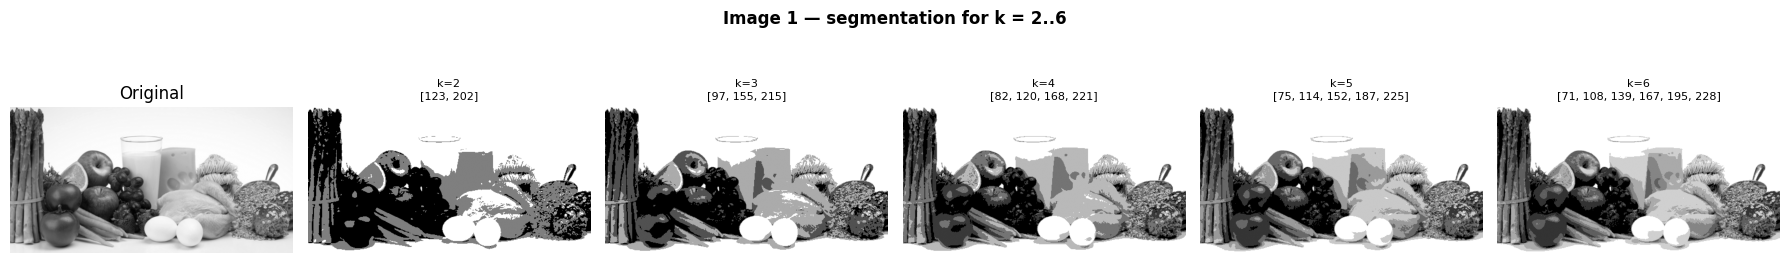

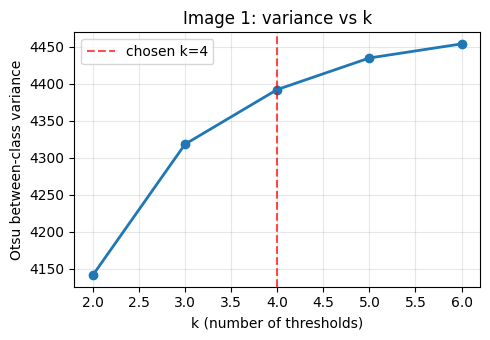

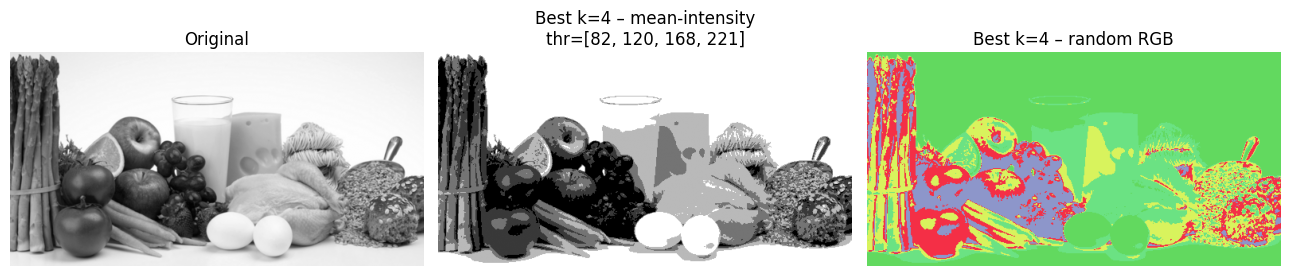

>>> BEST for Image 1: k=4, thresholds=[82, 120, 168, 221]



In [21]:
best_k1, best_thr1 = run_experiment(img1, "Image 1")

  Image 2  k=2  thresholds=[44, 146]  score=2850.98
  Image 2  k=3  thresholds=[42, 108, 190]  score=2968.74
  Image 2  k=4  thresholds=[32, 73, 122, 191]  score=3025.79
  Image 2  k=5  thresholds=[18, 48, 78, 118, 198]  score=3051.06
  Image 2  k=6  thresholds=[24, 53, 76, 107, 156, 213]  score=3076.85


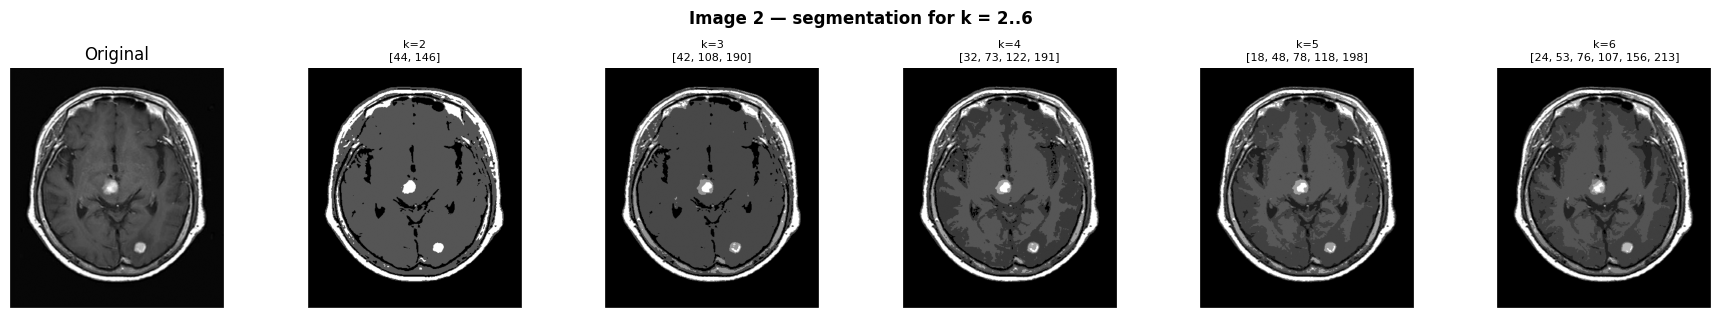

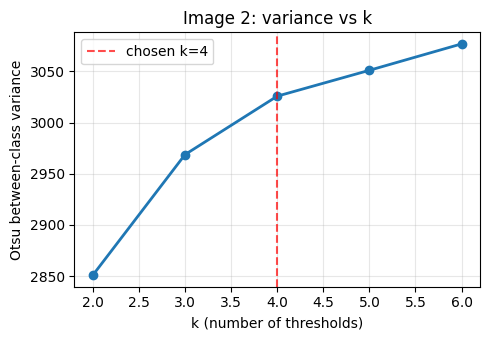

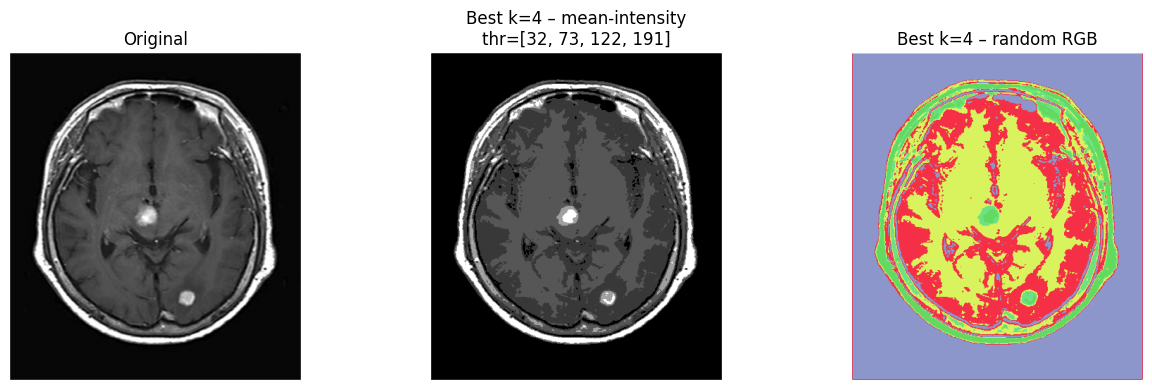

>>> BEST for Image 2: k=4, thresholds=[32, 73, 122, 191]



In [22]:
best_k2, best_thr2 = run_experiment(img2, "Image 2")

  Image 3  k=2  thresholds=[54, 103]  score=1038.09
  Image 3  k=3  thresholds=[45, 78, 122]  score=1126.38
  Image 3  k=4  thresholds=[42, 70, 102, 149]  score=1170.97
  Image 3  k=5  thresholds=[40, 63, 86, 116, 163]  score=1196.18
  Image 3  k=6  thresholds=[37, 56, 75, 95, 124, 172]  score=1210.67


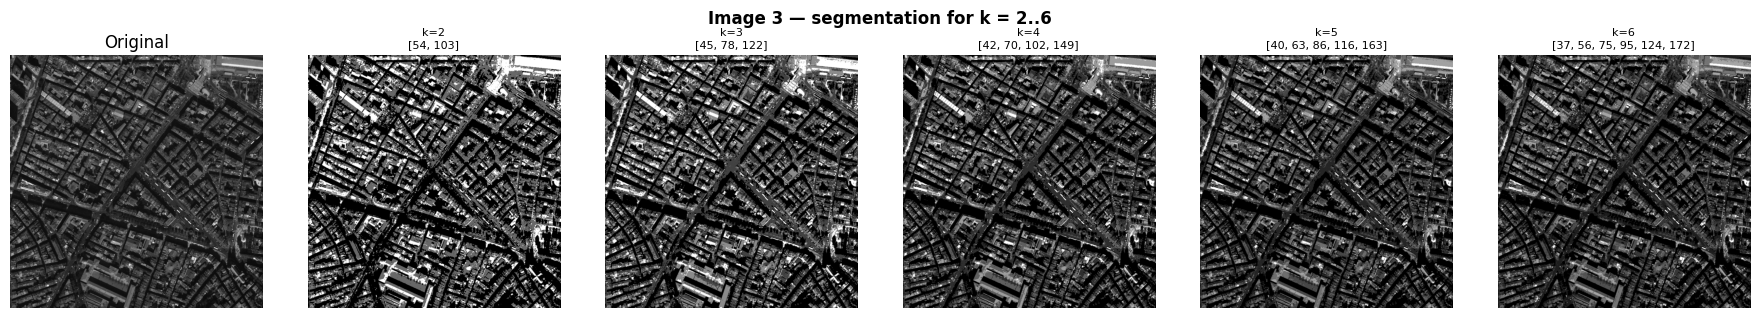

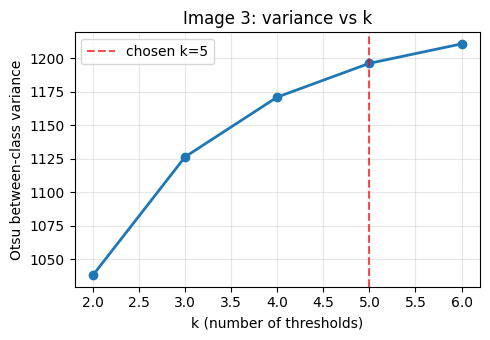

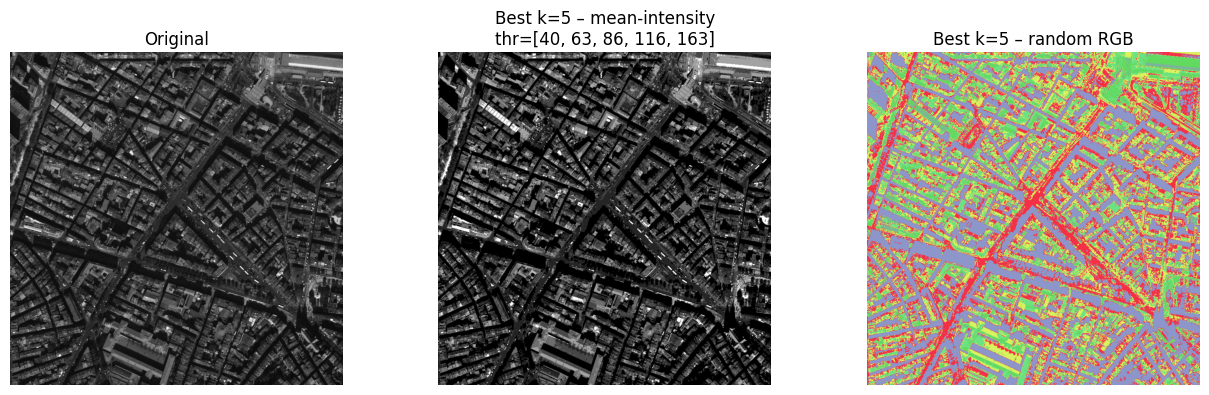

>>> BEST for Image 3: k=5, thresholds=[40, 63, 86, 116, 163]



In [23]:
best_k3, best_thr3 = run_experiment(img3, "Image 3")

In [24]:
print("=" * 55)
print("FINAL SUMMARY")
print("=" * 55)
for name, k, thr in [("Image 1", best_k1, best_thr1),
                      ("Image 2", best_k2, best_thr2),
                      ("Image 3", best_k3, best_thr3)]:
    print(f"{name}: best k={k},  thresholds={thr.tolist()}")

print("""
HOW THE OPTIMAL k IS DECIDED:
-------------------------------
Otsu variance always increases with k, so maximum variance alone
always favors the largest k — not useful. Instead we use the ELBOW
of the variance curve: the smallest k after which the marginal gain
drops below 25% of the first jump (k=2→3).

Beyond the elbow, GWO places thresholds inside already-cohesive
regions, splitting them into artificial sub-segments with no visual
benefit (over-segmentation). Visual inspection of the montage
confirms this: segments become fragmented and lose coherence.
""")

FINAL SUMMARY
Image 1: best k=4,  thresholds=[82, 120, 168, 221]
Image 2: best k=4,  thresholds=[32, 73, 122, 191]
Image 3: best k=5,  thresholds=[40, 63, 86, 116, 163]

HOW THE OPTIMAL k IS DECIDED:
-------------------------------
Otsu variance always increases with k, so maximum variance alone
always favors the largest k — not useful. Instead we use the ELBOW
of the variance curve: the smallest k after which the marginal gain
drops below 25% of the first jump (k=2→3).

Beyond the elbow, GWO places thresholds inside already-cohesive
regions, splitting them into artificial sub-segments with no visual
benefit (over-segmentation). Visual inspection of the montage
confirms this: segments become fragmented and lose coherence.



In [26]:
# Fix 1: clean threshold display
def clean_thr(thr):
    return [int(x) for x in thr]

# Fix 2: save all figures properly including variance curve
import matplotlib
matplotlib.use('Agg')

for img, name, best_k, best_thr in [
    (img1, "image1", best_k1, best_thr1),
    (img2, "image2", best_k2, best_thr2),
    (img3, "image3", best_k3, best_thr3)
]:
    k_values = (2, 3, 4, 5, 6)
    results_k = {}
    scores_k = {}
    for k in k_values:
        thr, score = gwo(otsu_fitness, dim=k, bounds=(1, 255),
                         n_agents=25, max_iter=60, image=img)
        results_k[k] = thr
        scores_k[k] = score

    # --- Montage ---
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
    for ax, k in zip(axes[1:], k_values):
        ax.imshow(segment_image(img, results_k[k]), cmap="gray")
        ax.set_title(f"k={k}\n{clean_thr(results_k[k])}", fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{name}_montage.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved {name}_montage.png")

    # --- Variance curve ---
    fig, ax = plt.subplots(figsize=(5, 3.5))
    scores_list = [scores_k[k] for k in k_values]
    ax.plot(list(k_values), scores_list, "o-", linewidth=2, color="steelblue")
    ax.axvline(best_k, color="red", ls="--", alpha=0.7, label=f"chosen k={best_k}")
    ax.set_xlabel("k (number of thresholds)")
    ax.set_ylabel("Otsu between-class variance")
    ax.set_title(f"{name}: variance vs k")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{name}_variance.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved {name}_variance.png")

    # --- Best result ---
    seg_mean = segment_image(img, best_thr)
    seg_rgb  = segment_image_rgb(img, best_thr)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(seg_mean, cmap="gray")
    axes[1].set_title(f"Best k={best_k} – mean-intensity\nthr={clean_thr(best_thr)}")
    axes[1].axis("off")
    axes[2].imshow(seg_rgb)
    axes[2].set_title(f"Best k={best_k} – random RGB")
    axes[2].axis("off")
    plt.tight_layout()
    plt.savefig(f"{name}_best.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved {name}_best.png")

Saved image1_montage.png
Saved image1_variance.png
Saved image1_best.png
Saved image2_montage.png
Saved image2_variance.png
Saved image2_best.png
Saved image3_montage.png
Saved image3_variance.png
Saved image3_best.png
